In [ ]:
#| default_exp cdp

# CDP — network sniffing and replay

The cdp module wraps Chrome's DevTools Protocol behind a synchronous interface. `automation_browser()` is the single entry point — it launches Chrome with a persistent debug profile so cookies and sessions survive across runs. For SSO or enterprise sites, log in once in the browser window; every subsequent call picks up that session automatically.

Use cdp when scrapling's stealth mode is not enough: the site checks for enterprise SSO, reads cookies from a previous session, or ties requests to a specific browser fingerprint.

In [ ]:
#| export
import asyncio, json, base64, time, subprocess, sys, shutil, os, threading, socket, tempfile, re
from fastcore.all import patch, store_attr, AttrDict, Path, first
from fastcdp import *
from fossick.core import *
from importlib.resources import files as _pkg_files
from functools import lru_cache, wraps
from collections import defaultdict

In [ ]:
#| export
_plat_loc = dict(
    darwin=[Path('/Applications/Google Chrome.app/Contents/MacOS/Google Chrome'),
            Path('/Applications/Chromium.app/Contents/MacOS/Chromium')],
    win32=[Path(os.environ.get('LOCALAPPDATA','')) / 'Google/Chrome/Application/chrome.exe',
           Path(os.environ.get('PROGRAMFILES','')) / 'Google/Chrome/Application/chrome.exe',
           Path(os.environ.get('PROGRAMFILES(X86)','')) / 'Google/Chrome/Application/chrome.exe'],
    linux=['google-chrome', 'google-chrome-stable', 'chromium-browser', 'chromium'])

def _linux_loc():
    for name in _plat_loc['linux']:
        p = Path(shutil.which(name) or Path('/usr/bin')/name)
        if p.exists(): return p
    return None

def _find_chrome(chrome_path=None):
    'Find Chrome/Chromium binary across platforms; raises FileNotFoundError if absent'
    if chrome_path: return chrome_path
    sp = sys.platform
    return _linux_loc() if sp == 'linux' else next(str(p) for p in _plat_loc[sp] if p.exists())

def _default_profile_dir():
    'Platform-appropriate CDP debug profile directory'
    if sys.platform == 'darwin': return str(Path.home()/'Library/Application Support/ChromeDebug')
    if sys.platform == 'win32': return str(Path(os.environ.get('LOCALAPPDATA', str(Path.home())))/'ChromeDebug')
    return str(Path.home()/'.config/chrome-debug')

In [ ]:
#| export
def launchctl(label): return subprocess.run(['launchctl', 'list', label], capture_output=True).returncode == 0

def chrome_info(port:int=9222, chrome_path=None, profile_dir=None):
    'Return a dict of info needed to launch Chrome with CDP on macOS'
    return AttrDict(port=port, chrome=_find_chrome(chrome_path), label=f'com.fossick.chrome-debug-{port}',
        profile_dir=profile_dir or _default_profile_dir(), origins=f'http://localhost:{port},http://127.0.0.1:{port}')

def _mac_chrome(port:int=9222, chrome_path=None, profile_dir=None, uninstall:bool=False):
    'Set up a launchd agent to start Chrome with CDP on login. Idempotent. macOS only.'
    ci, dom = chrome_info(port, chrome_path, profile_dir), f'gui/{os.getuid()}'
    plist = Path.home() / f'Library/LaunchAgents/{ci.label}.plist'
    if uninstall:
        subprocess.run(['launchctl', 'bootout', f'{dom}/{ci.label}'], check=False)
        plist.unlink(missing_ok=True)
        return True
    log = str(Path.home() / f'Library/Logs/chrome-debug-{port}.log')
    pp = _pkg_files('fossick').joinpath('chrome_debug.plist')
    t = pp.read_text().format(log=log, **ci)
    plist.mk_write(t)
    if launchctl(ci.label):
        subprocess.run(['launchctl', 'bootout', f'{dom}/{ci.label}'], check=False)
        for _ in range(20):
            time.sleep(0.1)
            if not launchctl(ci.label): break
    r = subprocess.run(['launchctl', 'bootstrap', dom, str(plist)])
    if r.returncode == 5:
        subprocess.run(['launchctl', 'bootout', f'{dom}/{ci.label}'], check=False)
        time.sleep(1.0)
        subprocess.run(['launchctl', 'bootstrap', dom, str(plist)], check=True)
    elif r.returncode: raise subprocess.CalledProcessError(r.returncode, r.args)
    return True

def _linux_chrome(port:int=9222, chrome_path=None, profile_dir=None, uninstall:bool=False):
    'Set up a systemd user service to start Chrome with CDP on login. Idempotent. Linux only.'
    ci = chrome_info(port, chrome_path, profile_dir)
    svc = Path.home() / f'.config/systemd/user/chrome-debug-{port}.service'
    if uninstall:
        subprocess.run(['systemctl', '--user', 'disable', '--now', svc.stem], check=False)
        svc.unlink(missing_ok=True)
        return True
    svc.mk_write(_pkg_files('fossick').joinpath('chrome_debug.service').read_text().format(**ci))
    subprocess.run(['systemctl', '--user', 'enable', '--now', svc.stem], check=True)
    return True

def _win_chrome(port:int=9222, chrome_path=None, profile_dir=None, uninstall:bool=False):
    'Set up a scheduled task to start Chrome with CDP on login. Idempotent. Windows only.'
    ci, task = chrome_info(port, chrome_path, profile_dir), f'ChromeDebug-{port}'
    if uninstall:
        subprocess.run(['schtasks', '/delete', '/tn', task, '/f'], check=False)
        return True
    with tempfile.NamedTemporaryFile(suffix='.xml', delete=False, mode='w', encoding='utf-8') as f:
        f.write(_pkg_files('fossick').joinpath('chrome_debug_task.xml').read_text().format(**ci))
        tmp = f.name
    subprocess.run(['schtasks', '/create', '/tn', task, '/xml', tmp, '/f'], check=True)
    Path(tmp).unlink(missing_ok=True)
    return True

def setup_chrome_daemon(port:int=9222, chrome_path=None, profile_dir=None, uninstall:bool=False) -> bool:
    "Install (or uninstall) a system service that starts Chrome with remote debugging at login"
    sp = sys.platform
    fn = _mac_chrome if sp == 'darwin' else _linux_chrome if sp == 'linux' else _win_chrome if sp == 'win32' else None
    if fn: return fn(port, chrome_path, profile_dir, uninstall)
    else: raise NotImplementedError(f'daemon setup not supported on {sp}')

In [ ]:
#| export
def ws_url(p=9222):
	def ws(): return http_get(f'http://127.0.0.1:{p}/json/version').json()['webSocketDebuggerUrl']
	try: return ws()
	except:
		setup_chrome_daemon(p)
		time.sleep(1)
		return ws()

In [ ]:
ws_url()

'ws://127.0.0.1:9222/devtools/browser/89b370cc-05f6-486f-a92b-db8f45520df2'

In [ ]:
#| export
async def cdp_connect(port=9222):
    'Connect to Chrome DevTools Protocol on the given port. Tries localhost and 127.0.0.1'
    try: cdp = await CDP.connect(wsconn=ws_url(port))
    except: raise ConnectionRefusedError(f'no DevTools endpoint on port {port}')
    cdp.ws.protocol.max_message_size = 2**30
    return cdp

In [ ]:
#| export
_loop = None
def _bridge():
	global _loop
	if _loop is None:
	    _loop = asyncio.new_event_loop()
	    threading.Thread(target=_loop.run_forever, daemon=True).start()
	return _loop

def syncy(coro): return asyncio.run_coroutine_threadsafe(coro, _bridge()).result()

In [ ]:
#| export
@patch
async def open_page(self:CDP, url):
	pg = await self.new_page()
	await pg.goto(url)
	return pg

In [ ]:
cdp = syncy(cdp_connect())

In [ ]:
pgs = syncy(cdp.pages)
if pgs:
    tid = pgs[0]['targetId']
    sid = syncy(cdp.attach(tid))
    pg=Page(cdp, tid, sid)
    root = syncy(pg.ax_tree())
    print(str(root)[:300])

In [ ]:
#| eval: false
page = syncy(cdp.new_page())
syncy(page.goto('https://vedicreader.com/s/'))
rt = syncy(page.ax_tree())
print(str(rt)[:300])

- **RootWebArea** "vedicreader" `focusable=True` `url=https://vedicreader.com/` [#2]
  - **navigation** "" [#183]
    - **link** "Vr." `focusable=True` `url=https://vedicreader.com/` [#184]
      - **heading** "Vr." `level=4` [#185]
        - **StaticText** "Vr." [#262]
          - **InlineTextBox**


In [ ]:
#| eval: false
syncy(page.click(rt.find_id('button', 'Test Drive')))

In [ ]:
#| export
@patch
async def calls(self:CDP, url=None, pattern='.*', tail=3):
    'Outgoing requests matching `pattern`. Navigates if url given, else passive.'
    page = await self.new_page()
    rx, out = compile_pattern(pattern), {}
    await page.network.enable()
    async with self.on('Network.requestWillBeSent') as q:
        async with self.on('Network.loadingFinished') as done:
            async def drain():
                while True:
                    m = await q.get()
                    if m.get('sessionId') not in (None, page.sid): continue
                    r, rid = m['params']['request'], m['params']['requestId']
                    if rx.search(r['url']): out[rid] = r|dict(rid=rid)
            d = asyncio.create_task(drain())
            if url: await page.goto(url)
            else: await asyncio.sleep(tail)
            await asyncio.sleep(tail)
            d.cancel()
            while not done.empty():
                m = await done.get()
                if (rid:=m['params']['requestId']) not in out: continue
                body = await self.network.getResponseBody(requestId=rid, sid=page.sid)
                out[rid]= out[rid] | dict(response_body=body)
    return out

In [ ]:
#| eval: false
apis = syncy(cdp.calls('https://www.woolworths.com.au/shop/search/products?searchTerm=Apples%20%26%20Pears', pattern='.apis/ui/Search/products'))

In [ ]:
#| export
BUTTON_JS = r'''
(() => {
  const inject = () => {
    if (document.getElementById('__capbar')) return;
    const bar = document.createElement('div'); bar.id='__capbar'; bar.className='__capui';
    Object.assign(bar.style, {position:'fixed', bottom:'20px', right:'20px',
      zIndex:2147483647, display:'flex', gap:'8px', alignItems:'center', font:'14px sans-serif'});
    const btn = t => { const b=document.createElement('button'); b.textContent=t;
      Object.assign(b.style,{padding:'10px 14px', background:'#111', color:'#fff', border:'none',
        borderRadius:'8px', cursor:'pointer', boxShadow:'0 2px 8px rgba(0,0,0,.35)'}); return b; };
    const badge = document.createElement('span'); badge.id='__capn';
    badge.textContent = (localStorage.getItem('__capN')||0) + ' snaps';
    Object.assign(badge.style,{padding:'6px 10px', background:'#333', color:'#fff', borderRadius:'8px'});
    const cap = btn('📸 capture'); cap.onclick = () => window.__cap(JSON.stringify({}));
    const done = btn('✓ done');   done.onclick = () => window.__cap(JSON.stringify({done:true}));
    bar.append(badge, cap, done); document.body.appendChild(bar);
  };
  if (document.readyState === 'loading') addEventListener('DOMContentLoaded', inject);
  else inject();
})()
'''
HIDE = "document.querySelectorAll('.__capui').forEach(b=>b.style.visibility='hidden')"
SHOW = "document.querySelectorAll('.__capui').forEach(b=>b.style.visibility='visible')"

In [ ]:
#| export
@patch
async def collect(page:Page, save_dir=None, prefix=None, stop=None, tout=None, count=None, every_n=None):
	stop, sid = stop or asyncio.Event(), page.sid
	prefix = prefix or await page.eval('document.title')
	save_dir = Path(save_dir) if save_dir else None
	if save_dir: save_dir.mkdir(parents=True, exist_ok=True)
	def save(img, label=None):
		if not save_dir: return img
		f = save_dir / f'{label or prefix}.png'
		f.write_bytes(img.data)
		print('saved', f.name)
		return img, f
	await page.runtime.enable()
	await page.runtime.addBinding(name='__cap')
	ident = await page.page.addScriptToEvaluateOnNewDocument(source=BUTTON_JS)
	await page.eval("localStorage.setItem('__capN','0')")
	await page.eval(BUTTON_JS)
	loop = asyncio.get_event_loop()
	dl = loop.time() + tout if tout else None
	shots, n = [], 0
	def _set(v): return f'''localStorage.setItem('__capN','{v}');var e=document.getElementById('__capn');
	 if(e)e.textContent='{v} snaps';'''

	try:
		async with page.cdp.on('Runtime.bindingCalled') as q:
			print(f'📸 capture, ✓ done (or stop.set()) to finish. → {save_dir}/')
			while not stop.is_set():
				rem = (dl - loop.time()) if dl else None
				if rem is not None and rem <= 0: break
				wait_for = min(every_n, rem) if (every_n and rem is not None) else (every_n or rem)
				get, halt = asyncio.ensure_future(q.get()), asyncio.ensure_future(stop.wait())
				kw = dict(timeout=wait_for) if wait_for is not None else {}
				fin, pend = await asyncio.wait({get, halt}, return_when=asyncio.FIRST_COMPLETED, **kw)
				for p in pend: p.cancel()
				if not fin:
					if every_n and (dl is None or loop.time() < dl):
						img = await page.screenshot()
						shots.append(save(img, f'{prefix}_{n}'))
						n += 1
						await page.eval(_set(n))
						if count and n >= count: break
						continue
					break
				if get not in fin: break
				m = get.result()
				if m.get('sessionId') not in (None, sid) or m['params'].get('name') != '__cap': continue
				data = json.loads(m['params'].get('payload') or '{}')
				if data.get('done'): break
				await page.eval(HIDE)
				await asyncio.sleep(0.05)
				img = await page.screenshot()
				await page.eval(SHOW)
				shots.append(save(img, data.get('label')))
				n += 1
				await page.eval(_set(n))
				if count and n >= count: break
	finally:
		try:
			await page.page.removeScriptToEvaluateOnNewDocument(identifier=ident)
			await page.runtime.removeBinding(name='__cap')
			await page.eval("document.getElementById('__capbar')?.remove(); localStorage.removeItem('__capN')")
		except: pass
	return shots

📸 capture, ✓ done (or stop.set()) to finish. → None/


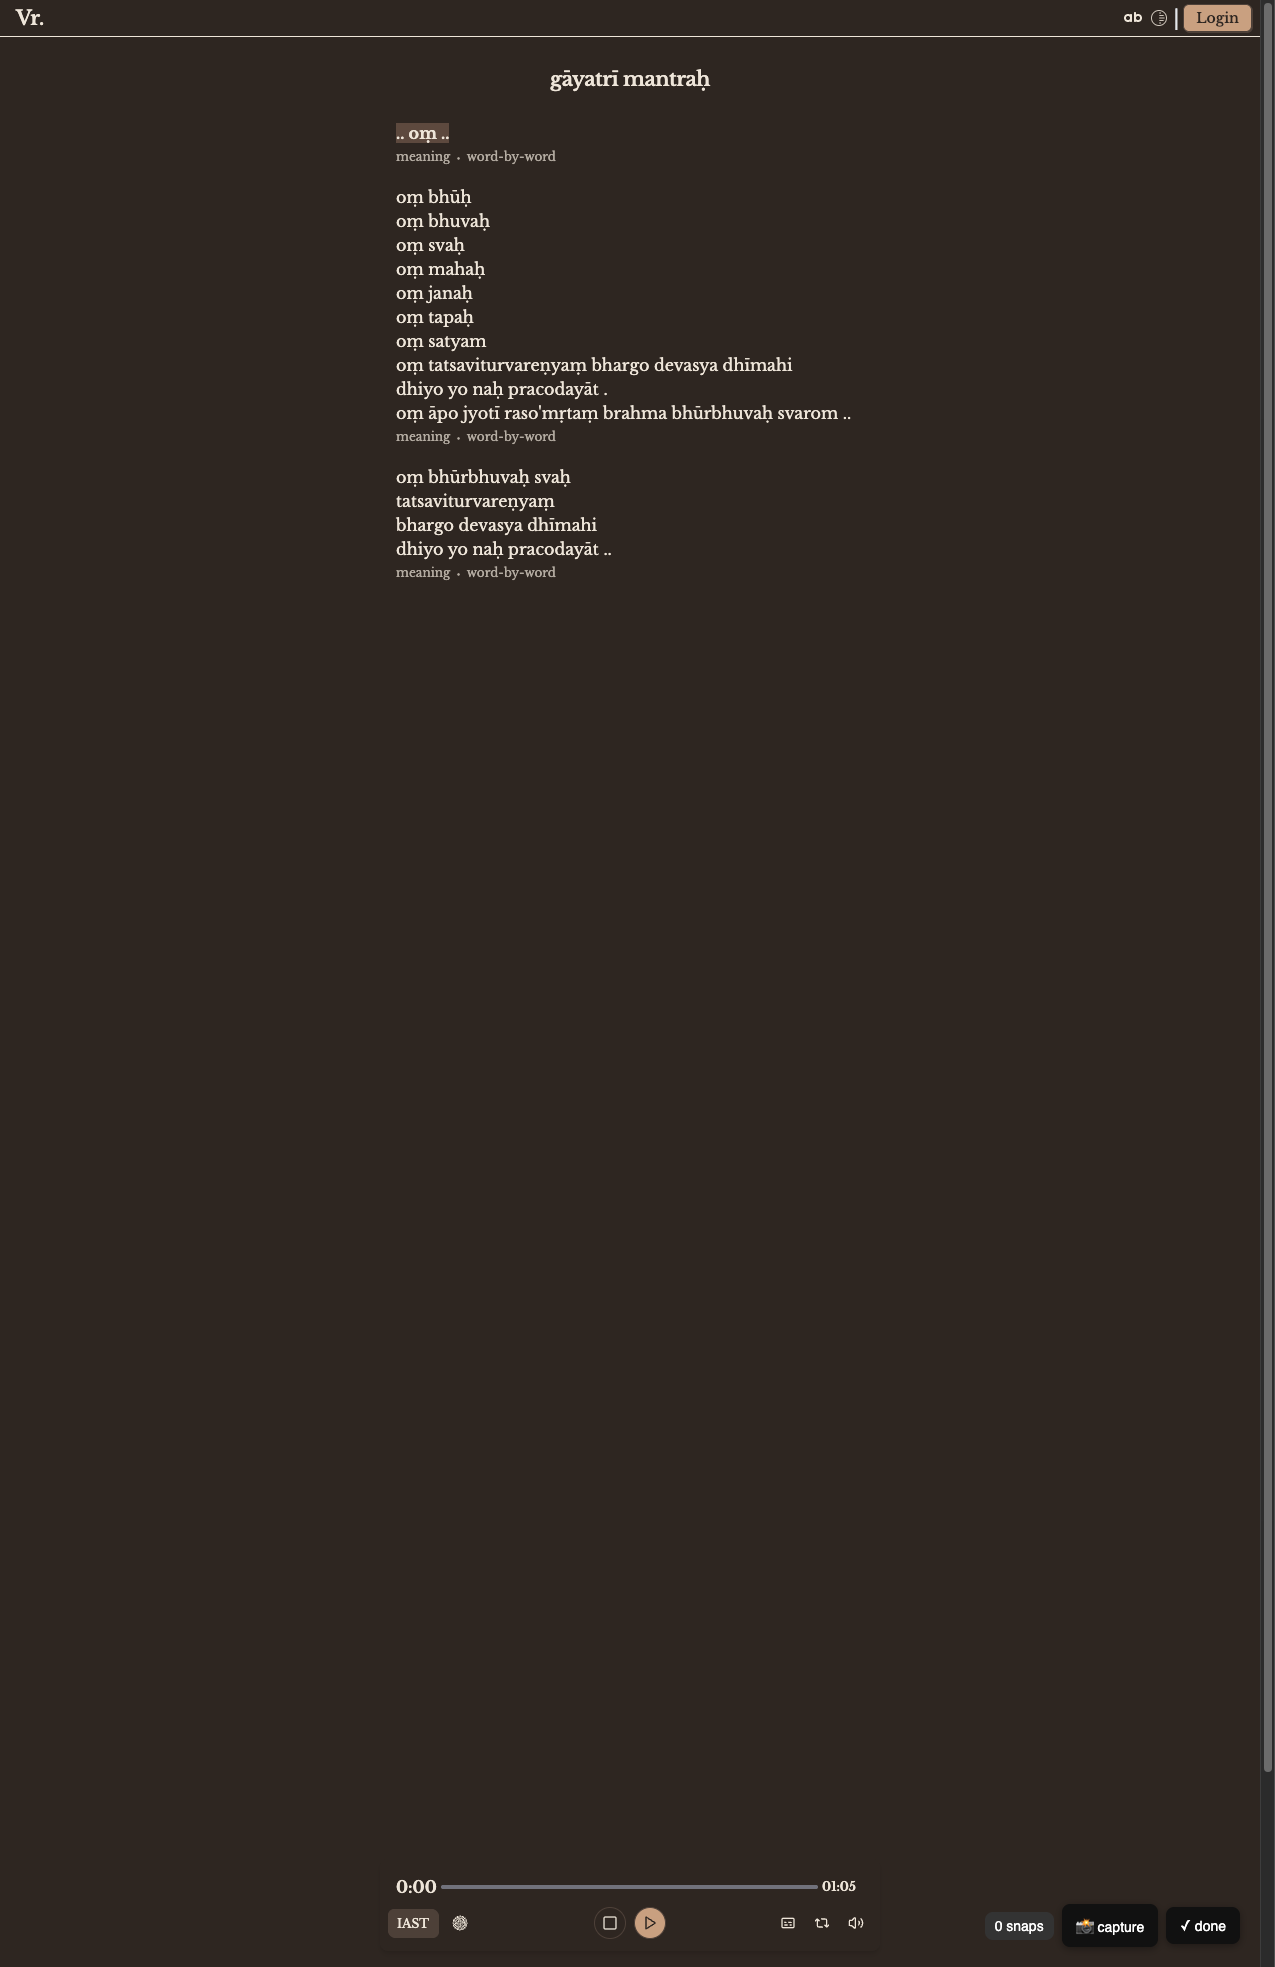

In [ ]:
#| eval: false
imgs = syncy(page.collect(count=1, tout=5, every_n=1))
if imgs: imgs[0].width, imgs[0].height = 200, 400
imgs[0]

In [ ]:
#| export
ANNOTATE_JS = r"""(function(){if(window.__axOn) return;
window.__axOn=true; window.__axN=0;const hov=document.createElement('div');hov.id='__axhov';
hov.style.cssText='position:fixed;pointer-events:none;z-index:999998;outline:2px solid #3b82f6;border-radius:2px;background:rgba(59,130,246,0.08);display:none;box-sizing:border-box;';
document.body.appendChild(hov);
window.__axBadge=function(n,role,sel){
  const el=document.querySelector('[data-axid="'+n+'"]');
  if(!el) return;
  el.style.outline='2px solid #2563eb';
  el.style.outlineOffset='1px';
  const b=document.createElement('div');
  b.className='__axbadge';
  const r=el.getBoundingClientRect();
  b.style.cssText='position:fixed;z-index:999999;pointer-events:none;'
    +'top:'+r.top+'px;right:'+(window.innerWidth-r.right)+'px;'
    +'background:rgba(30,64,175,.92);color:#fff;font:bold 11px/1.4 monospace;'
    +'padding:2px 6px;border-radius:0 2px 0 4px;white-space:nowrap;';
  b.textContent=n+' '+role+' · '+sel;
  document.body.appendChild(b);
  const c=document.getElementById('__axcount');
  if(c) c.textContent=n+' selected';
};
function getSel(el){
  if(el.id) return '#'+CSS.escape(el.id);
  if(el.dataset.testid) return '[data-testid="'+el.dataset.testid+'"]';
  let s=el.tagName.toLowerCase();
  const t=el.getAttribute('type');
  if(t) s+='[type="'+t+'"]';
  else if(el.className) s+='.'+el.className.trim().split(/\s+/)[0];
  return s;
}
document.addEventListener('mousemove',function(e){
  const el=document.elementFromPoint(e.clientX,e.clientY);
  if(!el||el.closest('#__axbar,#__axhov')){hov.style.display='none';return;}
  const r=el.getBoundingClientRect();
  Object.assign(hov.style,{display:'block',left:r.left+'px',top:r.top+'px',width:r.width+'px',height:r.height+'px'});
},true);
document.addEventListener('click',function(e){
  const el=document.elementFromPoint(e.clientX,e.clientY);
  if(!el||el.closest('#__axbar')) return;
  e.preventDefault(); e.stopPropagation();
  const n=++window.__axN;
  el.setAttribute('data-axid',n);
  window.__axsel(JSON.stringify({n:n,sel:getSel(el),x:e.clientX,y:e.clientY}));
},true);
})();"""

ANNOTATE_BAR_JS = '''(function(){
    if(document.getElementById('__axbar')) return;
    const bar=document.createElement('div');
    bar.id='__axbar';bar.style.cssText='position:fixed;bottom:16px;left:50%;transform:translateX(-50%);z-index:1000000;background:#1e40af;color:#fff;padding:8px 20px;border-radius:999px;font:bold 13px system-ui;box-shadow:0 4px 12px rgba(0,0,0,.3);display:flex;gap:12px;align-items:center;user-select:none;';
    bar.innerHTML='<span id="__axcount">0 selected</span><button style="background:#fff;color:#1e40af;border:none;padding:4px 14px;border-radius:999px;font:bold 12px system-ui;cursor:pointer;" onclick="window.__axsel(JSON.stringify({done:true}))">✓ Done</button>';
    document.body.appendChild(bar);})();'''

ANNOTATE_CLEANUP_JS = '''document.querySelectorAll('[data-axid]').forEach(e=>{e.removeAttribute('data-axid');
e.style.outline='';e.style.outlineOffset='';});document.querySelectorAll('[data-axb]').forEach(e=>e.remove());
document.querySelectorAll('.__axbadge').forEach(e=>e.remove());
['__axhov','__axbar'].forEach(id=>document.getElementById(id)?.remove());
['__axOn','__axN','__axBadge','__axsel'].forEach(k=>delete window[k]);'''
_AX_SKIP = {'none','generic','Section','InlineTextBox','StaticText',''}

In [ ]:
#| export
@patch
async def annotate(page:Page, save_dir=None, prefix=None, stop=None):
	"Click elements interactively; returns (screenshot, [{n, role, name, selector}]) with badges baked in."
	stop, sid = stop or asyncio.Event(), page.sid
	prefix = prefix or await page.eval('document.title')
	save_dir = Path(save_dir) if save_dir else None
	if save_dir: save_dir.mkdir(parents=True, exist_ok=True)
	await page.runtime.enable()
	await page.accessibility.enable()
	await page.runtime.addBinding(name='__axsel')
	ident = await page.page.addScriptToEvaluateOnNewDocument(source=ANNOTATE_JS)
	await page.eval(ANNOTATE_JS)
	await page.eval(ANNOTATE_BAR_JS)
	selected, img = [], None
	try:
		async with page.cdp.on('Runtime.bindingCalled') as q:
			print('Click elements to annotate, ✓ Done when ready.')
			while not stop.is_set():
				get = asyncio.ensure_future(q.get())
				halt = asyncio.ensure_future(stop.wait())
				fin, pend = await asyncio.wait({get, halt}, return_when=asyncio.FIRST_COMPLETED)
				for p in pend: p.cancel()
				if get not in fin: break
				m = get.result()
				if m.get('sessionId') not in (None, sid) or m['params'].get('name') != '__axsel': continue
				data = json.loads(m['params'].get('payload') or '{}')
				if data.get('done'): break
				n, sel = data['n'], data['sel']
				loc = await page.DOM.getNodeForLocation(x=int(data['x']), y=int(data['y']),
					includeUserAgentShadowDOM=False)
				nodes = await page.accessibility.getAXNodeAndAncestors(backendNodeId=loc['backendNodeId'])
				role = next((nd['role']['value'] for nd in nodes
				             if nd.get('role',{}).get('value','') not in _AX_SKIP), 'element')
				name = next((nd['name']['value'] for nd in nodes
				             if nd.get('name',{}).get('value','')), '')
				await page.eval(f"window.__axBadge({json.dumps(n)},{json.dumps(role)},{json.dumps(sel)})")
				selected.append({'n': n, 'role': role, 'name': name, 'selector': sel})
		img = await page.screenshot()
	finally:
		try:
			await page.page.removeScriptToEvaluateOnNewDocument(identifier=ident)
			await page.runtime.removeBinding(name='__axsel')
			await page.eval(ANNOTATE_CLEANUP_JS)
		except Exception: pass
	if save_dir and img:
		f = save_dir / f'{prefix}.png'
		f.write_bytes(img.data)
		print('saved', f.name)
	return img, selected

Click elements to annotate, ✓ Done when ready.
saved Gayathri Dhyaanam.png


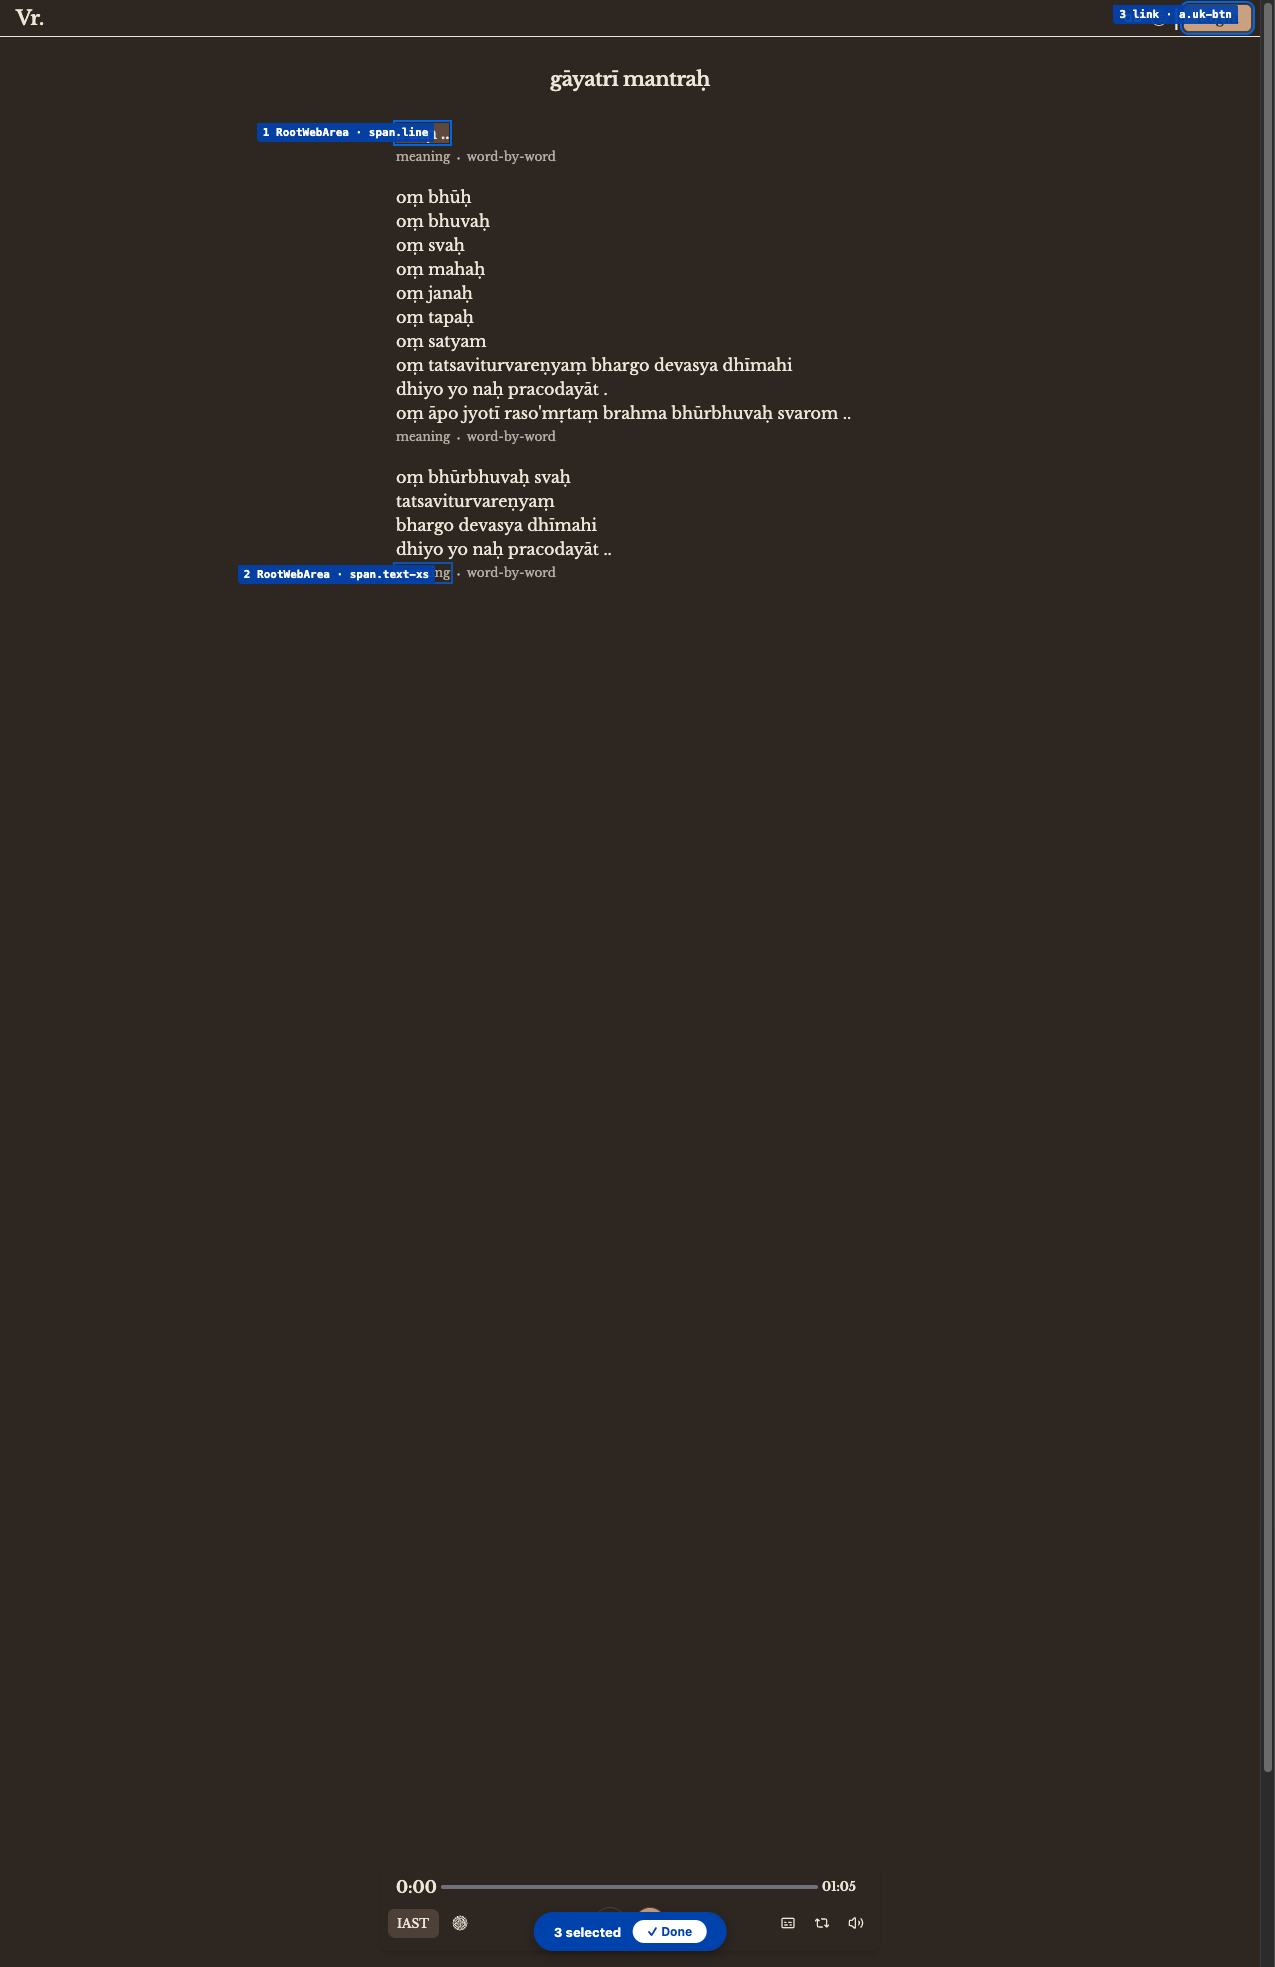

In [ ]:
#| eval: false
img, elements = syncy(page.annotate(save_dir='shots'))
img.height, img.width = 400, 200
img

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()